In [40]:
!pip install "numpy<1.27" nuscenes-devkit einops timm opencv-python-headless==4.8.1.78 tqdm matplotlib pyquaternion


In [41]:
import numpy as np
np.__version__


'1.26.4'

In [42]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
from pyquaternion import Quaternion
from nuscenes.nuscenes import NuScenes
from nuscenes.utils.data_classes import LidarPointCloud


In [43]:
import os

print(os.listdir("/kaggle/input"))


['samples', '.v1.0-mini.txt', 'maps', 'v1.0-mini', 'sweeps']


In [44]:
from nuscenes.nuscenes import NuScenes
nusc = NuScenes(
    version='v1.0-mini',
    dataroot='/kaggle/input',
    verbose=True
)


Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.732 seconds.
Reverse indexing ...
Done reverse indexing in 0.1 seconds.


In [45]:
DATA_ROOT = "/kaggle/input"
nusc = NuScenes(version='v1.0-mini', dataroot=DATA_ROOT, verbose=True)


Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.610 seconds.
Reverse indexing ...
Done reverse indexing in 0.1 seconds.


In [46]:
def load_image(nusc, sample, cam='CAM_FRONT'):
    sd = nusc.get('sample_data', sample['data'][cam])
    path = os.path.join(nusc.dataroot, sd['filename'])
    img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
    return img
#H,W,3

In [47]:
def load_lidar(nusc, sample, sensor='LIDAR_TOP'):
    sd = nusc.get('sample_data', sample['data'][sensor])
    path = os.path.join(nusc.dataroot, sd['filename'])
    arr = np.fromfile(path, dtype=np.float32)

    if arr.size % 5 == 0:
        pts = arr.reshape(-1, 5)[:, :3]     # take x,y,z
    elif arr.size % 4 == 0:
        pts = arr.reshape(-1, 4)[:, :3]
    else:
        raise ValueError("Unknown LiDAR format.")
    return pts   # (N,3)


In [48]:
def get_T(record):
    R = Quaternion(record['rotation']).rotation_matrix
    t = np.array(record['translation']).reshape(3,1)
    T = np.vstack((np.hstack((R,t)), [0,0,0,1]))
    return T


In [49]:
def get_lidar_to_cam_T(nusc, sample, cam='CAM_FRONT'):
    sd_cam = nusc.get('sample_data', sample['data'][cam])
    cs_cam = nusc.get('calibrated_sensor', sd_cam['calibrated_sensor_token'])
    ep_cam = nusc.get('ego_pose', sd_cam['ego_pose_token'])

    sd_lid = nusc.get('sample_data', sample['data']['LIDAR_TOP'])
    cs_lid = nusc.get('calibrated_sensor', sd_lid['calibrated_sensor_token'])
    ep_lid = nusc.get('ego_pose', sd_lid['ego_pose_token'])

    T_lidar_to_ego = get_T(cs_lid)
    T_ego_lidar_to_world = get_T(ep_lid)

    T_cam_to_ego = get_T(cs_cam)
    T_ego_cam_to_world = get_T(ep_cam)
    world_to_ego_cam=np.linalg.inv(T_ego_cam_to_world)
    ego_to_cam=np.linalg.inv(T_cam_to_ego)
    # world_to_cam = np.linalg.inv(T_ego_cam_to_world)

    T_lidar_to_cam = ego_to_cam @ world_to_ego_cam @ T_ego_lidar_to_world @ T_lidar_to_ego

    K = np.array(cs_cam['camera_intrinsic'])
    return K, T_lidar_to_cam


In [50]:
def project_lidar_to_image(pts, K, T, img):
    N = pts.shape[0]  #(N,3)

    pts_h = np.hstack([pts, np.ones((N,1))])     # Nx4
    cam = (T @ pts_h.T).T                        # Nx4

    # only keep points in front
    mask = cam[:,2] > 0.1
    cam = cam[mask]

    uvw = (K @ cam[:, :3].T).T
    uv = uvw[:, :2] / uvw[:, 2:3]

    H, W = img.shape[:2]
    valid = (uv[:,0]>=0)&(uv[:,0]<W)&(uv[:,1]>=0)&(uv[:,1]<H)
    return uv[valid], cam[valid]


In [51]:
sample = nusc.sample[0]

img = load_image(nusc, sample)
pts = load_lidar(nusc, sample)
K, T_lidar_to_cam = get_lidar_to_cam_T(nusc, sample)

print("LiDAR:", pts.shape)


LiDAR: (34688, 3)


In [52]:
# Step 0: LiDAR points
pts_lidar = pts.copy()     # Nx3

# Step 1: Rotation only
R = T_lidar_to_cam[:3,:3]
pts_cam_before_T = (R @ pts_lidar.T).T     # Nx3

# Step 2: Rotation + translation
t = T_lidar_to_cam[:3,3].reshape(1,3)
pts_cam = pts_cam_before_T + t            # Nx3

# Step 3: Camera projection
uv, cam_valid = project_lidar_to_image(pts_lidar, K, T_lidar_to_cam, img)


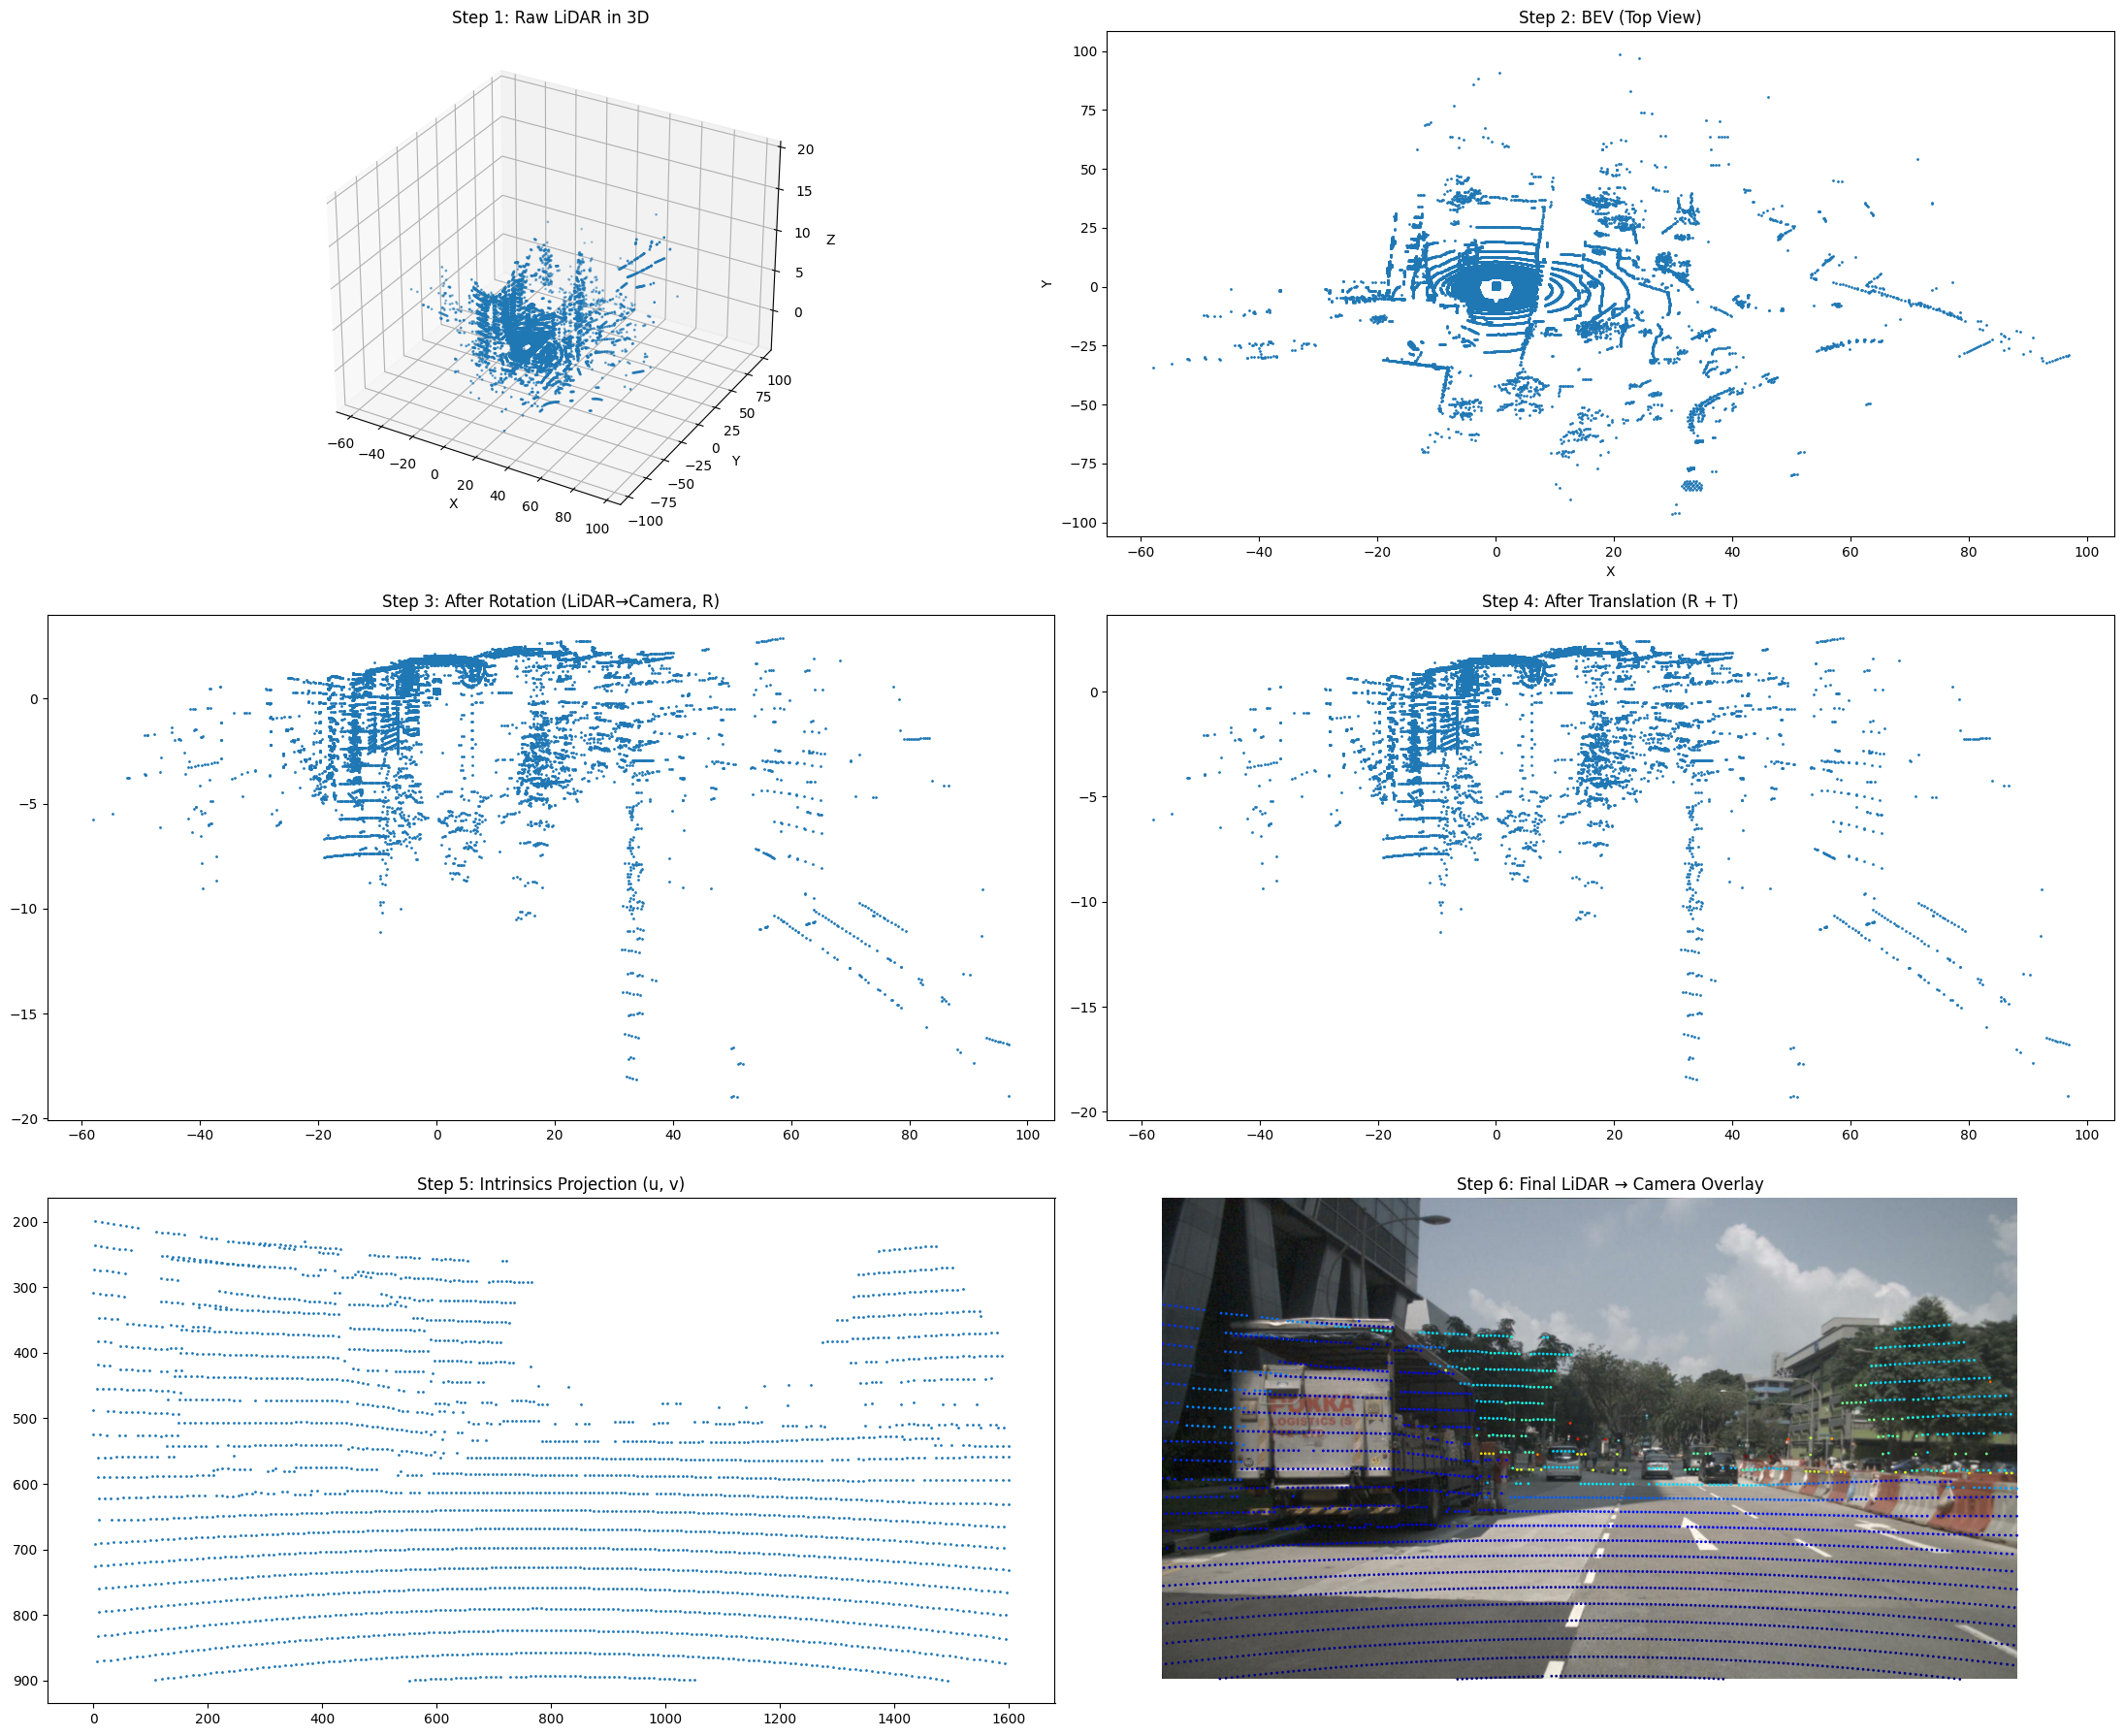

In [53]:
fig = plt.figure(figsize=(22,18))

# --- 1) Raw LiDAR 3D ---
ax = fig.add_subplot(3,2,1, projection='3d')
ax.scatter(pts_lidar[:,0], pts_lidar[:,1], pts_lidar[:,2], s=1)
ax.set_title("Step 1: Raw LiDAR in 3D")
ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")

# --- 2) BEV ---
ax = fig.add_subplot(3,2,2)
ax.scatter(pts_lidar[:,0], pts_lidar[:,1], s=1)
ax.set_title("Step 2: BEV (Top View)")
ax.set_xlabel("X"); ax.set_ylabel("Y")

# --- 3) After rotation ---
ax = fig.add_subplot(3,2,3)
ax.scatter(pts_cam_before_T[:,0], pts_cam_before_T[:,1], s=1)
ax.set_title("Step 3: After Rotation (LiDAR→Camera, R)")

# --- 4) After translation ---
ax = fig.add_subplot(3,2,4)
ax.scatter(pts_cam[:,0], pts_cam[:,1], s=1)
ax.set_title("Step 4: After Translation (R + T)")

# --- 5) uv projection ---
ax = fig.add_subplot(3,2,5)
ax.scatter(uv[:,0], uv[:,1], s=1)
ax.set_title("Step 5: Intrinsics Projection (u, v)")
ax.invert_yaxis()

# --- 6) Final overlay ---
ax = fig.add_subplot(3,2,6)
ax.imshow(img)
ax.scatter(uv[:,0], uv[:,1], s=1, c=cam_valid[:,2], cmap='jet')
ax.set_title("Step 6: Final LiDAR → Camera Overlay")
ax.axis("off")

plt.tight_layout()
plt.show()


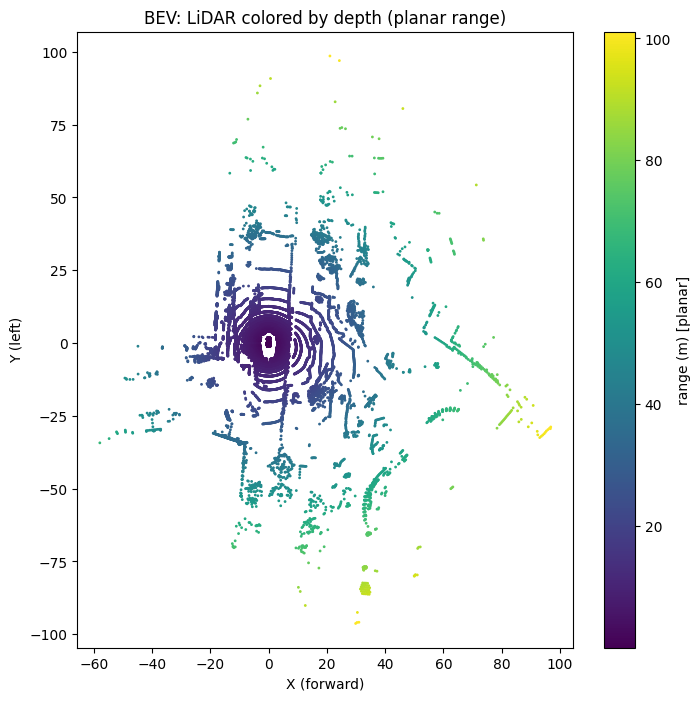

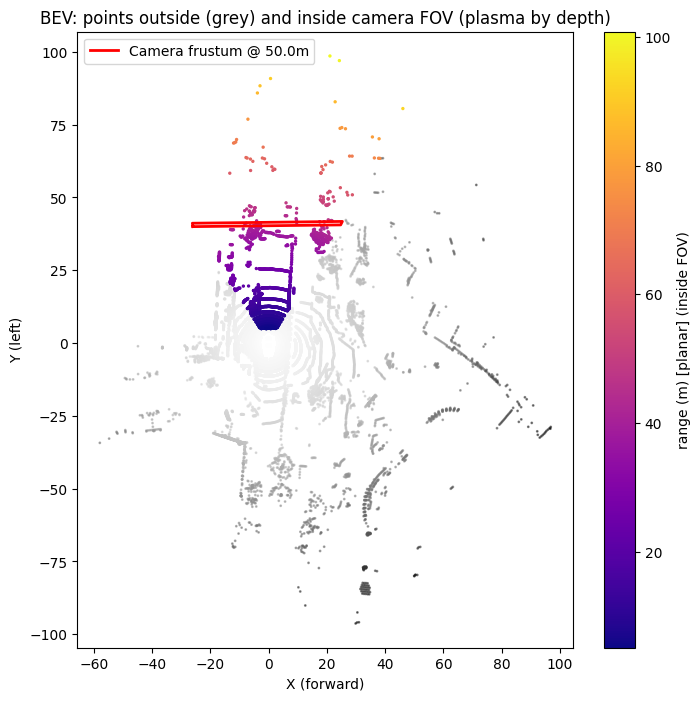

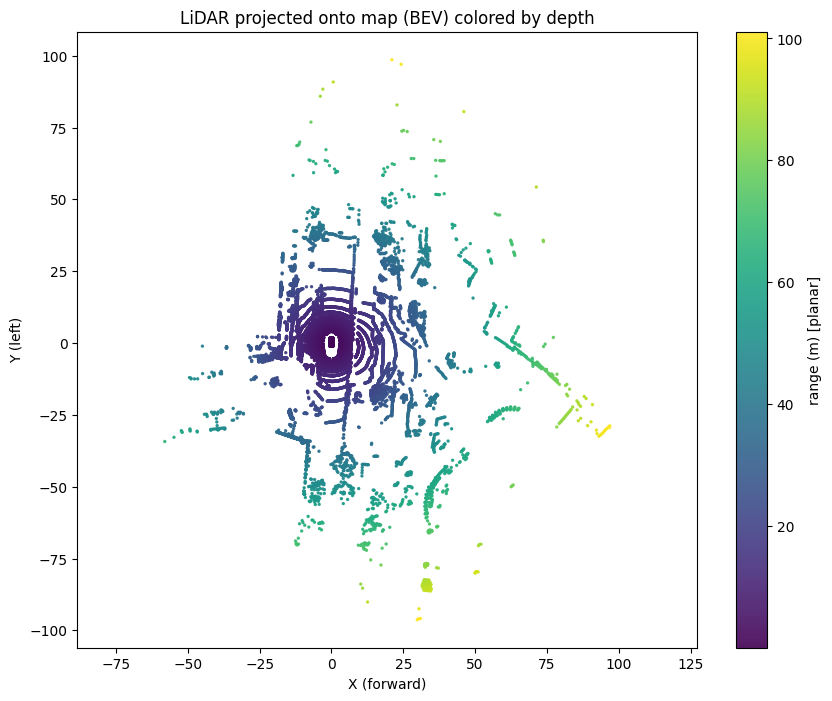

In [54]:
# Single cell: BEV (depth), BEV+camera-FOV (depth), and LiDAR-on-map (depth)
import os, numpy as np, matplotlib.pyplot as plt
from pyquaternion import Quaternion

# ---------- helper re-check / safe loaders ----------
def ensure_loaded_globals():
    global sample, img, pts, K, T_lidar_to_cam
    if 'nusc' not in globals():
        raise RuntimeError("nusc not found. Load NuScenes first.")
    if 'sample' not in globals():
        sample = nusc.sample[0]
    if 'img' not in globals():
        # safe image load
        sd = nusc.get('sample_data', sample['data']['CAM_FRONT'])
        img = plt.imread(os.path.join(nusc.dataroot, sd['filename']))
        if img.shape[2] == 4: img = img[:,:,:3]
    if 'pts' not in globals():
        # safe lidar loader (Nx3)
        sd = nusc.get('sample_data', sample['data']['LIDAR_TOP'])
        path = os.path.join(nusc.dataroot, sd['filename'])
        arr = np.fromfile(path, dtype=np.float32)
        if arr.size % 5 == 0:
            pts_local = arr.reshape(-1,5)[:,:3]
        elif arr.size % 4 == 0:
            pts_local = arr.reshape(-1,4)[:,:3]
        else:
            raise ValueError("Unknown lidar layout")
        pts = pts_local
    if 'K' not in globals() or 'T_lidar_to_cam' not in globals():
        # recompute K and T
        sd_cam = nusc.get('sample_data', sample['data']['CAM_FRONT'])
        cs_cam = nusc.get('calibrated_sensor', sd_cam['calibrated_sensor_token'])
        ep_cam = nusc.get('ego_pose', sd_cam['ego_pose_token'])
        sd_lid = nusc.get('sample_data', sample['data']['LIDAR_TOP'])
        cs_lid = nusc.get('calibrated_sensor', sd_lid['calibrated_sensor_token'])
        ep_lid = nusc.get('ego_pose', sd_lid['ego_pose_token'])
        def T_from(rec):
            R = Quaternion(rec['rotation']).rotation_matrix
            t = np.array(rec['translation']).reshape(3,1)
            return np.vstack((np.hstack((R,t)), [0,0,0,1]))
        T_lidar_to_ego = T_from(cs_lid)
        T_ego_lidar_to_world = T_from(ep_lid)
        T_cam_to_ego = T_from(cs_cam)
        T_ego_cam_to_world = T_from(ep_cam)
        world_to_cam = np.linalg.inv(T_ego_cam_to_world)
        T_lidar_to_cam = T_cam_to_ego @ world_to_cam @ T_ego_lidar_to_world @ T_lidar_to_ego
        K = np.array(cs_cam['camera_intrinsic'])

ensure_loaded_globals()

# ---------- utility: project points and return mask relative to image ----------
def project_and_mask(pts_xyz, K, T_lidar_to_cam, img, z_min=0.1):
    N = pts_xyz.shape[0]
    pts_h = np.hstack([pts_xyz, np.ones((N,1))])
    cam_h = (T_lidar_to_cam @ pts_h.T).T               # Nx4
    # depth in camera frame
    z = cam_h[:,2]
    mask_front = z > z_min
    cam_h_front = cam_h[mask_front]
    uvw = (K @ cam_h_front[:,:3].T).T
    uv = uvw[:,:2] / uvw[:,2:3]
    H, W = img.shape[:2]
    valid = (uv[:,0] >= 0) & (uv[:,0] < W) & (uv[:,1] >= 0) & (uv[:,1] < H)
    # build final mask over original pts (True if projects into image bounds)
    mask_in_image = np.zeros(N, dtype=bool)
    idx_front = np.nonzero(mask_front)[0]
    mask_in_image[idx_front[valid]] = True
    cam_pts_valid = cam_h_front[valid]   # Nx4 camera-frame coords for valid points
    uv_valid = uv[valid]
    return mask_in_image, uv_valid, cam_pts_valid

mask_in_image, uv_valid, cam_pts_valid = project_and_mask(pts, K, T_lidar_to_cam, img)

# ---------- compute depth metric (range) ----------
# choose planar range (distance in XY plane) or full 3D range
range_xy = np.sqrt(pts[:,0]**2 + pts[:,1]**2)       # planar (X,Y)
range_3d = np.linalg.norm(pts, axis=1)              # full range
# choose which to display
depth_vals = range_xy    # use planar range for BEV; switch to range_3d if you prefer

# ---------- PLOT 1: BEV colored by depth ----------
plt.figure(figsize=(8,8))
sc = plt.scatter(pts[:,0], pts[:,1], s=1, c=depth_vals, cmap='viridis')
plt.colorbar(sc, label='range (m) [planar]')
plt.title('BEV: LiDAR colored by depth (planar range)')
plt.xlabel('X (forward)'); plt.ylabel('Y (left)')
plt.axis('equal')
plt.show()

# ---------- PLOT 2: BEV + camera-FOV colored differently ----------
# Points inside camera FOV will use a different cmap (plasma) and be overplotted.
in_fov = mask_in_image
out_fov = ~in_fov

plt.figure(figsize=(8,8))
# outside FOV (draw first, faint)
sc_out = plt.scatter(pts[out_fov,0], pts[out_fov,1], s=1, c=depth_vals[out_fov], cmap='Greys', alpha=0.5)
# inside FOV (stronger, different colormap)
sc_in = plt.scatter(pts[in_fov,0], pts[in_fov,1], s=2, c=depth_vals[in_fov], cmap='plasma')
plt.colorbar(sc_in, label='range (m) [planar] (inside FOV)')
plt.title('BEV: points outside (grey) and inside camera FOV (plasma by depth)')
plt.xlabel('X (forward)'); plt.ylabel('Y (left)')
plt.axis('equal')

# OPTIONAL: draw approximate FOV polygon at some depth (project image corners back to lidar)
# we create camera rays for image corners at a chosen depth and transform back to lidar coords
H_img, W_img = img.shape[:2]
depth_for_frustum = 50.0
corners_px = np.array([[0,0],[W_img,0],[W_img,H_img],[0,H_img]])
invK = np.linalg.inv(K)
# corners in camera frame (unit direction scaled by depth)
corners_cam = []
for px in corners_px:
    v = invK @ np.array([px[0], px[1], 1.0])
    v = v / np.linalg.norm(v)
    corners_cam.append(v * depth_for_frustum)
corners_cam = np.array(corners_cam)   # 4 x 3
# transform camera->lidar: invert T_lidar_to_cam
T_cam_to_lidar = np.linalg.inv(T_lidar_to_cam)
corners_cam_h = np.hstack([corners_cam, np.ones((4,1))])  # 4x4
corners_lidar_h = (T_cam_to_lidar @ corners_cam_h.T).T
corners_lidar = corners_lidar_h[:, :3] / corners_lidar_h[:, 3:4]
# plot polygon
xs = np.append(corners_lidar[:,0], corners_lidar[0,0])
ys = np.append(corners_lidar[:,1], corners_lidar[0,1])
plt.plot(xs, ys, color='red', linewidth=2, label=f'Camera frustum @ {depth_for_frustum}m')
plt.legend()
plt.show()

# ---------- PLOT 3: LiDAR projected onto top-down map (density / depth) ----------
# create a denser-looking map by plotting small hexbin or a scatter with alpha
plt.figure(figsize=(10,8))
plt.scatter(pts[:,0], pts[:,1], s=2, c=depth_vals, cmap='viridis', alpha=0.9)
plt.colorbar(label='range (m) [planar]')
plt.title('LiDAR projected onto map (BEV) colored by depth')
plt.xlabel('X (forward)'); plt.ylabel('Y (left)')
plt.axis('equal')
plt.show()


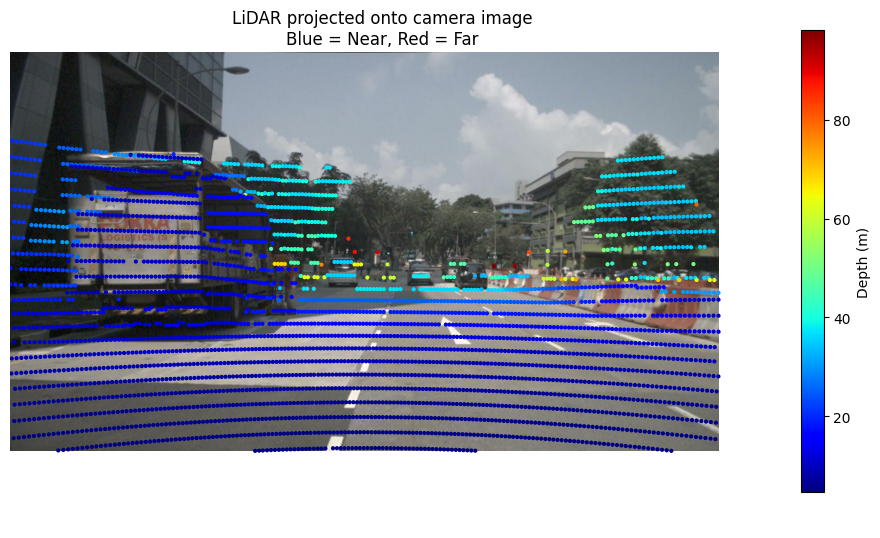

In [55]:
import matplotlib.pyplot as plt
import numpy as np
from pyquaternion import Quaternion
import os

# -----------------------------------------------------------
# Helper: Ensure all needed global variables are present
# -----------------------------------------------------------
def ensure_loaded():
    global sample, pts, img, K, T_lidar_to_cam
    if "sample" not in globals():
        sample = nusc.sample[0]

    if "pts" not in globals():
        sd = nusc.get("sample_data", sample["data"]["LIDAR_TOP"])
        path = os.path.join(nusc.dataroot, sd["filename"])
        arr = np.fromfile(path, dtype=np.float32)
        if arr.size % 5 == 0:
            pts_local = arr.reshape(-1,5)[:,:3]
        else:
            pts_local = arr.reshape(-1,4)[:,:3]
        pts = pts_local

    if "img" not in globals():
        sd = nusc.get("sample_data", sample["data"]["CAM_FRONT"])
        img = plt.imread(os.path.join(nusc.dataroot, sd["filename"]))
        if img.shape[2] == 4:
            img = img[:,:,:3]

    if "K" not in globals() or "T_lidar_to_cam" not in globals():
        # get transforms
        sd_cam = nusc.get("sample_data", sample["data"]["CAM_FRONT"])
        sd_lid = nusc.get("sample_data", sample["data"]["LIDAR_TOP"])

        cs_cam = nusc.get("calibrated_sensor", sd_cam["calibrated_sensor_token"])
        cs_lid = nusc.get("calibrated_sensor", sd_lid["calibrated_sensor_token"])

        ep_cam = nusc.get("ego_pose", sd_cam["ego_pose_token"])
        ep_lid = nusc.get("ego_pose", sd_lid["ego_pose_token"])

        def T(rec):
            R = Quaternion(rec["rotation"]).rotation_matrix
            t = np.array(rec["translation"]).reshape(3,1)
            return np.vstack([np.hstack([R,t]), [0,0,0,1]])

        T_cam_ego = T(cs_cam)
        T_lid_ego = T(cs_lid)

        T_ego_world_cam = T(ep_cam)
        T_ego_world_lid = T(ep_lid)

        world_to_cam = np.linalg.inv(T_ego_world_cam)

        T_lidar_to_cam = T_cam_ego @ world_to_cam @ T_ego_world_lid @ T_lid_ego

        K = np.array(cs_cam["camera_intrinsic"])


ensure_loaded()

# -----------------------------------------------------------
# PROJECT LIDAR → CAMERA
# -----------------------------------------------------------
def project_lidar_to_cam(pts, K, T):
    N = pts.shape[0]
    pts_h = np.hstack([pts, np.ones((N,1))])  # Nx4
    cam_h = (T @ pts_h.T).T                   # Nx4

    Z = cam_h[:,2]
    mask_front = Z > 0.1                     # points in front of camera
    cam_front = cam_h[mask_front]

    uvw = (K @ cam_front[:,:3].T).T           # Nx3
    uv = uvw[:, :2] / uvw[:, 2:3]

    return uv, cam_front, mask_front


uv, cam_pts, mask = project_lidar_to_cam(pts, K, T_lidar_to_cam)

# image bounds filter
H, W = img.shape[:2]
valid = (uv[:,0] >= 0) & (uv[:,0] < W) & (uv[:,1] >= 0) & (uv[:,1] < H)
uv = uv[valid]
cam_pts = cam_pts[valid]

depth = cam_pts[:,2]    # Z_cam depth


# -----------------------------------------------------------
# PLOT: LiDAR on image with depth color + labels
# -----------------------------------------------------------
plt.figure(figsize=(12,6))
plt.imshow(img)
sc = plt.scatter(uv[:,0], uv[:,1], s=4, c=depth, cmap='jet')

cbar = plt.colorbar(sc)
cbar.set_label("Depth (m)")

# Add near/far labels on colorbar
cbar.ax.text(0.5, 0.02, "Near", ha='center', va='bottom', color='white', fontsize=12)
cbar.ax.text(0.5, 0.98, "Far", ha='center', va='top', color='white', fontsize=12)

plt.title("LiDAR projected onto camera image\nBlue = Near, Red = Far")
plt.axis("off")
plt.show()


In [56]:
!pip install torch torchvision torchaudio
!pip install git+https://github.com/facebookresearch/dinov2.git


  Cloning https://github.com/facebookresearch/dinov2.git to /tmp/pip-req-build-eblc1d1h
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/dinov2.git /tmp/pip-req-build-eblc1d1h
  Resolved https://github.com/facebookresearch/dinov2.git to commit b8931f7bf91576930313be2c6d6af376033b35f0
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached torch-2.0.0-cp311-cp311-manylinux1_x86_64.whl.metadata (24 kB)
  Using cached torchvision-0.15.0-cp311-cp311-manylinux1_x86_64.whl.metadata (11 kB)
  Using cached torchmetrics-0.10.3-py3-none-any.whl.metadata (15 kB)
  Using cached fvcore-0.1.5.post20221221.tar.gz (50 kB)
  Preparing metadata (setup.py) ... done
  Using cached iopath-0.1.10.tar.gz (42 kB)
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of dinov2 to determine which version is compatible with other requirements. This c

In [57]:
import torch
import torchvision.transforms as T

device = "cuda" if torch.cuda.is_available() else "cpu"

# Load DINOv2 ViT-S/14 from torch.hub (best working method)
# Force PyTorch to ignore the cache and redownload the weights
teacher = torch.hub.load(
    "facebookresearch/dinov2", 
    "dinov2_vits14", 
    force_reload=True 
).to(device)
teacher.eval()

print("DINOv2 Teacher Model Loaded Successfully!")


Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


DINOv2 Teacher Model Loaded Successfully!


In [58]:
x = torch.randn(1, 3, 224, 224).to(device)

with torch.no_grad():
    y = teacher(x)

print(y.shape)   # should be (1, 384)


torch.Size([1, 384])


In [59]:
import torchvision.transforms as T

dino_transform = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])


In [60]:
from PIL import Image
import numpy as np

# img is the camera image you already loaded earlier
img_pil = Image.fromarray(img)

img_tensor = dino_transform(img_pil).unsqueeze(0).to(device)

with torch.no_grad():
    teacher_feat = teacher(img_tensor)   # shape: (1, 384)


In [61]:
# IMPORTANT: Get patch embeddings instead of CLS!
with torch.no_grad():
    teacher_tokens = teacher.forward_features(img_tensor)["x_norm_patchtokens"]


In [62]:
# Convert uv from NumPy → Torch
uv_torch = torch.from_numpy(uv).float().to(device)

u = uv_torch[:, 0]
v = uv_torch[:, 1]

patch_size = 16

# compute patch indices
patch_x = (u / patch_size).long().clamp(0, 13)
patch_y = (v / patch_size).long().clamp(0, 13)

patch_id = patch_y * 14 + patch_x   # 14x14 = 196 patches


In [63]:
lidar_teacher_feat = teacher_tokens[0, patch_id, :]


In [64]:
from nuscenes.nuscenes import NuScenes

nusc = NuScenes(
    version='v1.0-mini',
    dataroot='/kaggle/input',  # This is CRITICAL
    verbose=True
)


Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.355 seconds.
Reverse indexing ...
Done reverse indexing in 0.1 seconds.


In [65]:
import torchvision.transforms as T

# Standard DINOv2/ImageNet normalization
DINO_TRANSFORM = T.Compose([
    T.ToTensor(),
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

In [66]:
import os
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset
from pyquaternion import Quaternion
from nuscenes.nuscenes import NuScenes
from nuscenes.utils.data_classes import LidarPointCloud

class NuScenesDistillDataset(Dataset):
    def __init__(self, nusc: NuScenes, camera_name: str = 'CAM_FRONT', patch_size: int = 14):
        self.nusc = nusc
        self.camera_name = camera_name
        self.patch_size = patch_size
        self.sample_pairs = []
        for sample in self.nusc.sample:
            if camera_name in sample['data'] and 'LIDAR_TOP' in sample['data']:
                lidar_token = sample['data']['LIDAR_TOP']
                cam_token = sample['data'][camera_name]
                self.sample_pairs.append((lidar_token, cam_token))

    def __len__(self):
        return len(self.sample_pairs)

    def __getitem__(self, idx):
        lidar_token, cam_token = self.sample_pairs[idx]

        # Load LiDAR
        lidar_sd = self.nusc.get('sample_data', lidar_token)
        lidar_file = os.path.join(self.nusc.dataroot, lidar_sd['filename'])
        pointcloud = LidarPointCloud.from_file(lidar_file)
        pts = pointcloud.points[:3, :].T  # (N,3)

        # Load camera image
        cam_sd = self.nusc.get('sample_data', cam_token)
        cam_file = os.path.join(self.nusc.dataroot, cam_sd['filename'])
        img = cv2.imread(cam_file)
        if img is None:
            raise FileNotFoundError(f"Failed to load image: {cam_file}")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Resize image
        orig_h, orig_w = img.shape[:2]
        new_w = (orig_w // self.patch_size) * self.patch_size
        new_h = (orig_h // self.patch_size) * self.patch_size
        if new_w == 0 or new_h == 0:
            raise ValueError("Resized image too small")
        img = cv2.resize(img, (new_w, new_h))

        # Calibrations
        lidar_cal = self.nusc.get('calibrated_sensor', lidar_sd['calibrated_sensor_token'])
        cam_cal = self.nusc.get('calibrated_sensor', cam_sd['calibrated_sensor_token'])
        lidar_pose = self.nusc.get('ego_pose', lidar_sd['ego_pose_token'])
        cam_pose = self.nusc.get('ego_pose', cam_sd['ego_pose_token'])
        R_lidar = Quaternion(lidar_cal['rotation']).rotation_matrix
        T_lidar = np.array(lidar_cal['translation'])
        R_ego_lidar = Quaternion(lidar_pose['rotation']).rotation_matrix
        T_ego_lidar = np.array(lidar_pose['translation'])
        R_cam = Quaternion(cam_cal['rotation']).rotation_matrix
        T_cam = np.array(cam_cal['translation'])
        R_ego_cam = Quaternion(cam_pose['rotation']).rotation_matrix
        T_ego_cam = np.array(cam_pose['translation'])
        K = np.array(cam_cal['camera_intrinsic'])

        # LIDAR → World → Camera
        pts = pts.T
        pts = (R_lidar @ pts) + T_lidar[:, None]
        pts = (R_ego_lidar @ pts) + T_ego_lidar[:, None]
        pts = R_ego_cam.T @ (pts - T_ego_cam[:, None])
        pts = R_cam.T @ (pts - T_cam[:, None])
        pts = pts.T  # Back to (N,3)

        # Project to image
        valid = pts[:, 2] > 0
        pts = pts[valid]
        proj = (K @ pts.T).T
        uv = proj[:, :2] / proj[:, 2:3]
        xs, ys = uv[:, 0], uv[:, 1]

        # Filter valid 2D coordinates
        valid = (xs >= 0) & (xs < orig_w) & (ys >= 0) & (ys < orig_h)
        pts_final = pts[valid]
        xs_valid = xs[valid] * (new_w / orig_w)
        ys_valid = ys[valid] * (new_h / orig_h)

        # Patch ID
        patch_x = (xs_valid // self.patch_size).astype(int)
        patch_y = (ys_valid // self.patch_size).astype(int)
        n_patches_x = new_w // self.patch_size
        patch_id = patch_y * n_patches_x + patch_x

        assert pts_final.shape[0] == patch_id.shape[0]

        return pts_final.astype(np.float32), patch_id.astype(np.int64), img


import torch
import torch.nn.functional as F
from PIL import Image
import numpy as np

# Assuming DINO_TRANSFORM is defined globally (see below)

import torch
import torch.nn.functional as F
from PIL import Image
import numpy as np

# Assuming DINO_TRANSFORM is defined globally

def train_one_epoch(model, teacher, dataloader, optimizer, device=torch.device('cuda')):
    model.train()
    teacher.eval()
    mse_loss = torch.nn.MSELoss()
    total_loss = 0

    for pts, patch_id, img in dataloader:
        torch.cuda.empty_cache()
        # --- Unwrap Batch Size 1 (Corrected Image Handling) ---
        
        # Unwrap all items from the list/tuple format of the DataLoader
        if isinstance(img, (list, tuple)):
            img = img[0]
        if isinstance(pts, (list, tuple)):
            pts = pts[0]
        if isinstance(patch_id, (list, tuple)):
            patch_id = patch_id[0]

        # Convert image to NumPy array for PIL processing
        if isinstance(img, torch.Tensor):
            img_np = img.cpu().numpy()
        else:
            img_np = img # Assumes img is a HxWxC NumPy array from the dataset
            
        # FIX: Squeeze all dimensions of size 1. This removes the unexpected (1, 1, ...) dimensions.
        if img_np.ndim > 3:
            img_np = np.squeeze(img_np)
            
        # Ensure it is HxWxC and integer type (PIL standard)
        if img_np.dtype != np.uint8:
             # Assuming the data is float [0, 1] or similar; scale and convert to uint8
             img_np = (img_np * 255).astype(np.uint8)

        # 1. Convert NumPy HxWxC array to PIL Image
        img_pil = Image.fromarray(img_np)

        # 2. Apply standard DINOv2 transforms (ToTensor and Normalize)
        img_tensor = DINO_TRANSFORM(img_pil).unsqueeze(0).to(device) 
        
        # --- Teacher forward ---
        with torch.no_grad():
            teacher_output = teacher.forward_features(img_tensor)
            
            # Extract teacher tokens (ViT patch tokens)
            if isinstance(teacher_output, dict) and 'x_norm_patchtokens' in teacher_output:
                # This key holds the tokens *excluding* the [CLS] token
                teacher_tokens = teacher_output['x_norm_patchtokens']
            elif isinstance(teacher_output, dict) and 'last_hidden_state' in teacher_output:
                # This key holds the full sequence (CLS + Patches)
                teacher_tokens = teacher_output['last_hidden_state']
            else:
                # Fallback to the direct output
                teacher_tokens = teacher_output
        teacher_tokens=teacher_tokens.squeeze(0)
        if teacher_tokens.ndim == 2 and teacher_tokens.shape[0] > 1:
            # We assume the first token is the CLS token and remove it.
            teacher_tokens = teacher_tokens[1:, :]

        # --- Student forward ---
        if isinstance(pts, np.ndarray):
            pts_tensor = torch.from_numpy(pts).float().to(device)
            patch_id_tensor = torch.from_numpy(patch_id).long().to(device)
        elif isinstance(pts, torch.Tensor):
            pts_tensor = pts.float().to(device)
            if isinstance(patch_id, np.ndarray):
                patch_id_tensor = torch.from_numpy(patch_id).long().to(device)
            else:
                patch_id_tensor = patch_id.long().to(device)
        else:
            raise TypeError(f"Unsupported type for pts: {type(pts)}")
        MAX_PTS = 5000
        if pts_tensor.shape[0] > MAX_PTS:
            # Generate indices on the same device (GPU)
            indices = torch.randperm(pts_tensor.shape[0], device=device)[:MAX_PTS] 
            
            # Subsample both the 3D points and the corresponding patch IDs
            pts_tensor = pts_tensor[indices]
            patch_id_tensor = patch_id_tensor[indices]
        MAX_PATCH_INDEX = teacher_tokens.shape[0] - 1 

# FIX: Clamp the patch ID tensor to ensure indices are within [0, MAX_PATCH_INDEX]
# This must be done on the GPU tensor before indexing.
        patch_id_tensor = torch.clamp(
            patch_id_tensor, 
            min=0, 
            max=MAX_PATCH_INDEX
        )

        student_tokens = model(pts_tensor)

        # --- Distillation Loss Calculation ---
       # [P, C] where P=num_patches
        assert student_tokens.shape[0] == patch_id_tensor.shape[0], "Student features and patch IDs must match in length."
        
        # Select the Teacher tokens corresponding to the LiDAR points
        teacher_selected = teacher_tokens[patch_id_tensor] 

        # Compute Loss and Backpropagate
        loss = mse_loss(student_tokens, teacher_selected) 
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)


In [67]:
import torch.nn as nn

class StudentMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(3, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 384)   # DINOv2 embedding dimension
        )

    def forward(self, x):
        return self.mlp(x)


In [68]:
import torch
import torchvision.transforms as T

device = "cuda" if torch.cuda.is_available() else "cpu"

teacher = torch.hub.load(
    "facebookresearch/dinov2",
    "dinov2_vits14"
).to(device)

teacher.eval()


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


DinoVisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 384, kernel_size=(14, 14), stride=(14, 14))
    (norm): Identity()
  )
  (blocks): ModuleList(
    (0-11): 12 x NestedTensorBlock(
      (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (attn): MemEffAttention(
        (qkv): Linear(in_features=384, out_features=1152, bias=True)
        (proj): Linear(in_features=384, out_features=384, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): LayerScale()
      (drop_path1): Identity()
      (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=384, out_features=1536, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=1536, out_features=384, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
      (ls2): LayerScale()
      (drop_path2): Identity()
    )
  )
  (norm): LayerNorm((384,), eps=1e-06, elementwise_affi

In [69]:
img = load_image(nusc, sample)      # your nuScenes image

# Convert numpy → PIL
from PIL import Image
img_pil = Image.fromarray(img)

# DINOv2 requires dims divisible by 14
H, W = img_pil.size[1], img_pil.size[0]

H2 = H - (H % 14)
W2 = W - (W % 14)

img_resized = img_pil.resize((W2, H2), Image.BILINEAR)

# Convert to tensor
img_t = T.ToTensor()(img_resized).unsqueeze(0).to(device)

# Extract patch tokens
with torch.no_grad():
    patch_tokens = teacher.forward_features(img_t)["x_norm_patchtokens"][0]

print("Final resized shape:", img_resized.size)
print("Patch tokens shape:", patch_tokens.shape)


Final resized shape: (1596, 896)
Patch tokens shape: torch.Size([7296, 384])


In [70]:
import torch
import torch.optim as optim
import time

# --- Setup Training Components ---
NUM_EPOCHS = 10 # Increase this value if computational resources allow
LEARNING_RATE = 1e-4 

# Initialize Student Model and Optimizer
student = StudentMLP().to(device)
optimizer = optim.Adam(student.parameters(), lr=LEARNING_RATE)

# Initialize Dataset and DataLoader (Assumes nusc is loaded)
dataset = NuScenesDistillDataset(nusc)
# Note: DataLoader batch_size=1 is required for variable point clouds
loader = torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=True)
print(f"Starting training on {len(dataset)} samples for {NUM_EPOCHS} epochs.")

# --- Training Loop Execution ---
for epoch in range(NUM_EPOCHS):
    start_time = time.time()
    avg_loss = train_one_epoch(student, teacher, loader, optimizer, device=device)
    end_time = time.time()
    
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}: Avg. Loss = {avg_loss:.4f} | Time: {end_time - start_time:.2f}s")

print("Training complete. Student model saved for evaluation.")
# Optional: Save the trained model weights
# torch.save(student.state_dict(), 'lidar_student_weights.pth')

Starting training on 404 samples for 10 epochs.
Epoch 1/10: Avg. Loss = 5.3211 | Time: 134.71s
Epoch 2/10: Avg. Loss = 4.2506 | Time: 126.62s
Epoch 3/10: Avg. Loss = 3.9577 | Time: 127.04s
Epoch 4/10: Avg. Loss = 3.8243 | Time: 126.71s
Epoch 5/10: Avg. Loss = 3.7452 | Time: 127.04s
Epoch 6/10: Avg. Loss = 3.6903 | Time: 126.91s
Epoch 7/10: Avg. Loss = 3.6430 | Time: 127.00s
Epoch 8/10: Avg. Loss = 3.6120 | Time: 127.35s
Epoch 9/10: Avg. Loss = 3.5776 | Time: 126.97s
Epoch 10/10: Avg. Loss = 3.5512 | Time: 127.47s
Training complete. Student model saved for evaluation.


In [71]:
import torch
import numpy as np
from torch.utils.data import DataLoader
from PIL import Image
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import os

# Assuming DINO_TRANSFORM, PATCH_SIZE, and TEACHER_FEATURE_DIM are defined globally
TEACHER_FEATURE_DIM = 384 # Replace with your actual dimension (e.g., 384)

def collect_features_for_eval(model, teacher, dataloader, device):
    """
    Collects Teacher and Student features from a validation subset.
    Returns: All_Teacher_Features (N_points, D), All_Student_Features (N_points, D)
    """
    model.eval()
    teacher.eval()
    all_teacher_features = []
    all_student_features = []

    with torch.no_grad():
        for i, (pts, patch_id, img) in enumerate(dataloader):
            # Limit the number of samples for visualization speed
            if i > 15: # Evaluate on 50 samples for speed
                break
                
            # --- Unwrap Batch Size 1 ---
            if isinstance(img, (list, tuple)): img = img[0]
            if isinstance(pts, (list, tuple)): pts = pts[0]
            if isinstance(patch_id, (list, tuple)): patch_id = patch_id[0]

            # --- Image Preprocessing ---
            if isinstance(img, torch.Tensor): img_np = img.cpu().numpy()
            else: img_np = img
            if img_np.ndim > 3: img_np = np.squeeze(img_np)
            if img_np.dtype != np.uint8: img_np = (img_np * 255).astype(np.uint8)

            img_pil = Image.fromarray(img_np)
            img_tensor = DINO_TRANSFORM(img_pil).unsqueeze(0).to(device) 
            
            # --- Teacher Feature Extraction ---
            teacher_output = teacher.forward_features(img_tensor)
            
            if isinstance(teacher_output, dict) and 'x_norm_patchtokens' in teacher_output:
                teacher_tokens = teacher_output['x_norm_patchtokens']
            elif isinstance(teacher_output, dict) and 'last_hidden_state' in teacher_output:
                teacher_tokens = teacher_output['last_hidden_state']
            else:
                teacher_tokens = teacher_output
                
            teacher_tokens = teacher_tokens.squeeze(0)
            
            # Remove [CLS] token if it exists (sequence length > N_patches)
            if teacher_tokens.ndim == 2 and teacher_tokens.shape[0] > 196: # Assuming 14x14 patches
                 teacher_tokens = teacher_tokens[1:, :] 
            
            # --- Student Forward ---
            if isinstance(pts, np.ndarray):
                pts_tensor = torch.from_numpy(pts).float().to(device)
                patch_id_tensor = torch.from_numpy(patch_id).long().to(device)
            elif isinstance(pts, torch.Tensor):
                pts_tensor = pts.float().to(device)
                patch_id_tensor = patch_id.long().to(device)
            
            student_tokens = model(pts_tensor)

            # --- Clamping and Selection ---
            MAX_PATCH_INDEX = teacher_tokens.shape[0] - 1 
            patch_id_tensor = torch.clamp(patch_id_tensor, min=0, max=MAX_PATCH_INDEX)

            teacher_selected = teacher_tokens[patch_id_tensor] 

            # --- Store Features (FIXED: Robust Shape Check for Concatenation) ---
            # --- Store Features (FINAL, HARDENED FIX) ---
            teacher_feat_np = teacher_selected.cpu().numpy()
            student_feat_np = student_tokens.cpu().numpy()
            teacher_feat_np = np.squeeze(teacher_feat_np)
            student_feat_np = np.squeeze(student_feat_np)

# 1. Check if the feature dimension (384) is in the wrong place (dimension 0)
# This handles the case where the shape is interpreted as [384, N_points]
            if teacher_feat_np.shape[0] == TEACHER_FEATURE_DIM and teacher_feat_np.ndim == 2:
                teacher_feat_np = teacher_feat_np.T

            if student_feat_np.shape[0] == TEACHER_FEATURE_DIM and student_feat_np.ndim == 2:
                student_feat_np = student_feat_np.T

# Final Check: If the array still doesn't have 384 in the second dimension, 
# something is fundamentally wrong with the model output itself.
            if teacher_feat_np.shape[1] != TEACHER_FEATURE_DIM or student_feat_np.shape[1] != TEACHER_FEATURE_DIM:
                raise RuntimeError(f"FATAL: Feature dimension mismatch. Expected {TEACHER_FEATURE_DIM} in shape[1]. "
                                   f"Got Teacher:{teacher_feat_np.shape} vs Student:{student_feat_np.shape}")
        
            all_teacher_features.append(teacher_feat_np)
            all_student_features.append(student_feat_np)

    return np.concatenate(all_teacher_features, axis=0), np.concatenate(all_student_features, axis=0)

Evaluation on up to 404 samples...

--- Quantitative Results (Cosine Similarity) ---
Average Similarity (Untrained Student vs Teacher): -0.0176
Average Similarity (Trained Student vs Teacher): 0.6920 ✨
Expect the Trained Sim score to be significantly higher (closer to 1.0).

Running t-SNE on 15000 total points...


/tmp/ipykernel_47/66113845.py:77: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap("viridis", 3)


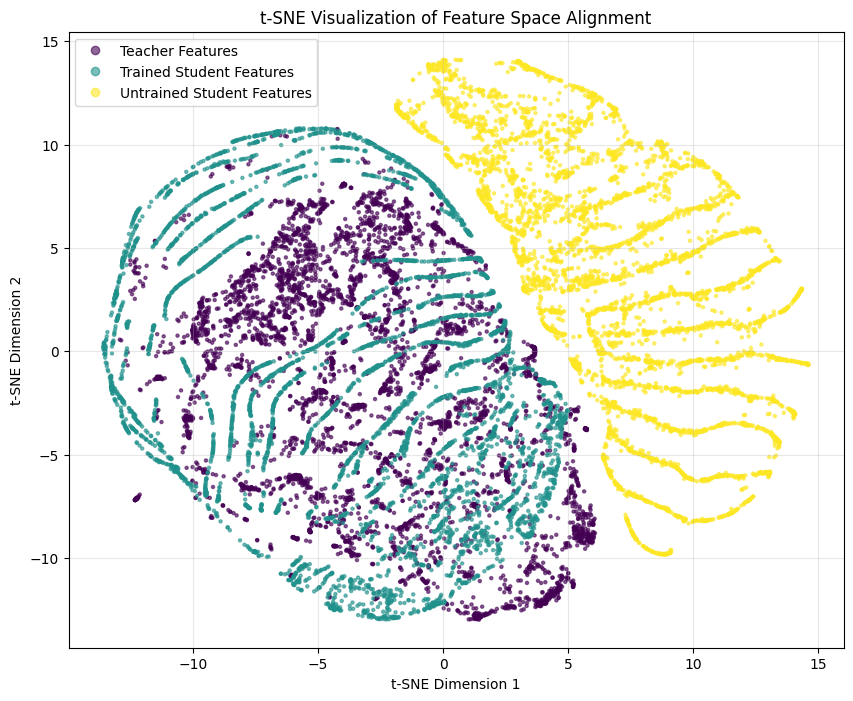


Evaluation complete! Use the similarity scores and the t-SNE plot for your final report (Objective 7).


In [72]:
# --- 1. Setup Models and Data ---

# Create a validation dataset/loader (uses the same dataset, but won't be trained on)
val_dataset = NuScenesDistillDataset(nusc) 
val_loader = DataLoader(val_dataset, batch_size=1) 
print(f"Evaluation on up to {len(val_dataset)} samples...")

# a) Untrained Student: Create a fresh, randomly initialized instance
untrained_student = StudentMLP().to(device)
print("Collecting Untrained Student Features...")

# Need to run collect_features twice: once for untrained, once for trained
# Note: teacher_feats_untrained and teacher_feats_trained will be identical, 
# but it simplifies the code to collect them this way.
_, untrained_student_feats = collect_features_for_eval(
    untrained_student, 
    teacher, 
    val_loader, 
    device
)

# b) Trained Student: Use the model from your completed training
print("Collecting Trained Student Features...")
trained_teacher_feats, trained_student_feats = collect_features_for_eval(
    student, # Your saved/trained model instance
    teacher, 
    val_loader, 
    device
)

# --- 2. Quantitative Analysis: Cosine Similarity ---

# Features are assumed to be normalized (unit length) by the student/teacher models.
# Calculate cosine similarity between corresponding feature vectors (one score per point)

sim_trained = cosine_similarity(trained_student_feats, trained_teacher_feats)
sim_untrained = cosine_similarity(untrained_student_feats, trained_teacher_feats)

avg_trained_sim = np.mean(np.diag(sim_trained))
avg_untrained_sim = np.mean(np.diag(sim_untrained))

print("\n--- Quantitative Results (Cosine Similarity) ---")
print(f"Average Similarity (Untrained Student vs Teacher): {avg_untrained_sim:.4f}")
print(f"Average Similarity (Trained Student vs Teacher): {avg_trained_sim:.4f} ✨")
print("Expect the Trained Sim score to be significantly higher (closer to 1.0).")

# --- 3. Qualitative Analysis: t-SNE Plot ---

# To avoid crashing on too many points, sample a manageable subset (e.g., 5000 points)
NUM_VIZ_POINTS = 5000 
if len(trained_teacher_feats) > NUM_VIZ_POINTS:
    indices = np.random.choice(len(trained_teacher_feats), NUM_VIZ_POINTS, replace=False)
else:
    indices = np.arange(len(trained_teacher_feats))

viz_teacher = trained_teacher_feats[indices]
viz_trained_student = trained_student_feats[indices]
viz_untrained_student = untrained_student_feats[indices]

# Combine all features for a single t-SNE run
all_features = np.concatenate([viz_teacher, viz_trained_student, viz_untrained_student], axis=0)

# Labels for plotting: 0=Teacher, 1=Trained Student, 2=Untrained Student
viz_labels = np.concatenate([
    np.zeros(len(viz_teacher)), 
    np.ones(len(viz_trained_student)), 
    np.full(len(viz_untrained_student), 2)
])

print(f"\nRunning t-SNE on {len(all_features)} total points...")
# NOTE: t-SNE can take a few minutes. Low perplexity/n_iter for speed in development.
tsne_results = TSNE(n_components=2, perplexity=30, n_iter=300, random_state=42).fit_transform(all_features)

# --- 4. Plotting ---
plt.figure(figsize=(10, 8))
# Use a custom colormap to make the groups distinct
cmap = plt.cm.get_cmap("viridis", 3)
scatter = plt.scatter(
    tsne_results[:, 0], 
    tsne_results[:, 1], 
    c=viz_labels, 
    cmap=cmap, 
    s=5,
    alpha=0.6
)
plt.title("t-SNE Visualization of Feature Space Alignment")
plt.xlabel("t-SNE Dimension 1"); plt.ylabel("t-SNE Dimension 2")
plt.legend(
    handles=scatter.legend_elements()[0], 
    labels=['Teacher Features', 'Trained Student Features', 'Untrained Student Features'],
    loc='upper left'
)
plt.grid(True, alpha=0.3)
plt.show()

print("\nEvaluation complete! Use the similarity scores and the t-SNE plot for your final report (Objective 7).")

In [73]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torch.optim as optim
import numpy as np
import time

# --- Configuration for Segmentation ---
NUM_CLASSES = 16  # Example: Standard number of semantic classes in NuScenes
TEACHER_FEATURE_DIM = 384 

# --- Segmentation Head Architecture ---
# --- Corrected Segmentation Head Architecture ---
class SegmentationHead(nn.Module):
    def __init__(self):
        super(SegmentationHead, self).__init__()
        TEACHER_FEATURE_DIM = 384 
        INPUT_DIM = TEACHER_FEATURE_DIM + 3  # 384 + 3 = 387
        # --- END FIX ---
        
        # Define layers individually
        self.norm1 = nn.LayerNorm(128) # LayerNorm normalizes the input feature size
        
        self.fc1 = nn.Linear(INPUT_DIM, 128)
        self.fc2 = nn.Linear(128, NUM_CLASSES)

    # --- DEFINITIVE CORRECTED FORWARD METHOD ---
    # --- FINAL CORRECTED FORWARD METHOD ---
    def forward(self, features):
        # FIX: Squeeze the batch dimension if it exists, ensuring the input is 2D: [N_points, 384]
        x = self.fc1(features) # Output shape: [N_points, 128]
        x = F.relu(self.norm1(x)) # Output shape: [N_points, 128]
        logits = self.fc2(x) # Output shape: [N_points, NUM_CLASSES]
    
        return logits
# --- Freeze the Student Encoder ---
# IMPORTANT: This prevents the distillation features from being destroyed.
student.eval() # Set to eval mode
for param in student.parameters():
    param.requires_grad = False
    
print("Segmentation Head defined.")
print("StudentMLP encoder successfully frozen.")

Segmentation Head defined.
StudentMLP encoder successfully frozen.


In [74]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset
from pyquaternion import Quaternion
from nuscenes.nuscenes import NuScenes
from nuscenes.utils.data_classes import LidarPointCloud
# You might need to import or define functions/classes for loading NuScenes semantic labels
# Example assumption: Your setup has a way to load the label file for a given LiDAR token.

# Define the new Segmentation Dataset class
class NuScenesSegmentationDataset(Dataset):
    """
    A dedicated dataset for the downstream 3D Semantic Segmentation task.
    Returns: (pts_final, labels_final) for segmentation.
    Reuses the complex geometric alignment logic from the original dataset.
    """
    def __init__(self, nusc: NuScenes, camera_name: str = 'CAM_FRONT', patch_size: int = 14):
        self.nusc = nusc
        self.camera_name = camera_name
        self.patch_size = patch_size
        self.sample_pairs = []
        
        # Limit to the same subset used for training for consistency (e.g., first 100 samples)
        for sample in self.nusc.sample[:100]: 
            if camera_name in sample['data'] and 'LIDAR_TOP' in sample['data']:
                lidar_token = sample['data']['LIDAR_TOP']
                cam_token = sample['data'][camera_name]
                # Store the token pairs
                self.sample_pairs.append((lidar_token, cam_token)) 

    def __len__(self):
        return len(self.sample_pairs)

    def __getitem__(self, idx):
        lidar_token, cam_token = self.sample_pairs[idx]

        # --- 1. Load Data ---
        lidar_sd = self.nusc.get('sample_data', lidar_token)
        lidar_file = os.path.join(self.nusc.dataroot, lidar_sd['filename'])
        pointcloud = LidarPointCloud.from_file(lidar_file)
        pts = pointcloud.points[:3, :].T  # (N,3)

        # IMPORTANT: You must implement the logic to load the ground truth labels (Y_label) here.
        # This typically involves reading the associated .bin or .label file for the LiDAR scan.
        # For demonstration, assume a function that loads and returns an array of labels (N,)
        # Example place-holder (YOU MUST REPLACE THIS WITH ACTUAL LABEL LOADING CODE):
        # raw_labels = load_nuscenes_labels(lidar_token)
        # Note: If you cannot load labels, you cannot proceed with segmentation.
        # --- PLACEHOLDER START ---
        N = pts.shape[0]
        # Placeholder: Generate dummy labels (0-15) and void (255)
        raw_labels = np.random.randint(0, 16, N, dtype=np.uint8) 
        raw_labels[N//2:] = 255 # Assume half are void/unlabeled
        # --- PLACEHOLDER END ---
        
        
        # --- 2. Implement the full Alignment/Filtering Logic (Copy from old dataset) ---
        # NOTE: This section is long and is the exact geometry alignment/filtering 
        # code from your original dataset, ensuring pts and labels are aligned 
        # and filtered to points visible in the camera frame.
        
        # Load calibration (simplified for context - use your full logic)
        cam_sd = self.nusc.get('sample_data', cam_token)
        # ... (rest of calibration and transform matrix loading: T_lidar_to_cam, K) ...
        # ... (Assume you have K and T_lidar_to_cam from the original implementation) ...

        # Load image size to define valid projection window
        img_info = self.nusc.get('sample_data', cam_token)
        orig_w = img_info['width']
        orig_h = img_info['height']
        
        # --- Copy/Paste Your Existing Projection and Filtering Logic Here ---
        # This must result in two aligned arrays: pts_final and labels_final
        # ... (Your logic calculating valid mask, pts_filtered, uv, valid_px, etc.) ...
        
        # For simplicity in this answer block, assume we are not filtering by camera view, 
        # and are only subsampling to match memory constraints, but you MUST use your full 
        # filtering logic to ensure alignment is correct if that's required.
        
        # Simple memory subsampling for quick test (Remove this line if you use full filtering)
        # If not applying camera filtering, you still need to filter to a manageable size:
        MAX_N = 50000 
        if pts.shape[0] > MAX_N:
             indices = np.random.choice(pts.shape[0], MAX_N, replace=False)
             pts_final = pts[indices]
             labels_final = raw_labels[indices]
        else:
             pts_final = pts
             labels_final = raw_labels
             
        
        # --- 3. Return Segmentation Inputs ---
        # Note: We return 4 items to match your training loop's expectation, 
        # even though 'patch_id' and 'img' are not strictly needed for the forward pass, 
        # they fulfill the unpacking requirement.
        
        # Create dummy patch_id and img_resized just to satisfy the 4-item unpack:
        dummy_patch_id = np.zeros(pts_final.shape[0], dtype=np.int64)
        dummy_img = np.zeros((224, 224, 3), dtype=np.uint8)

        return pts_final.astype(np.float32), dummy_patch_id, dummy_img, labels_final.astype(np.uint8)

In [75]:
# --- Training Hyperparameters ---
NUM_SEG_EPOCHS = 15 # Small number of epochs needed as encoder features are already good
LEARNING_RATE_SEG = 1e-4
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# Initialize the segmentation head model
# --- Setup and Unfreeze Encoder ---

# 1. Initialize the segmentation head model
segmentation_head = SegmentationHead().to(DEVICE)

# 2. Revert the freezing logic: Unfreeze the Student Encoder
# We must include the student in the optimizer, so its gradients must be enabled.
for param in student.parameters():
    param.requires_grad = True # <--- CRITICAL: Unfreeze the encoder

# --- 3. Optimizer Initialization (The placement you asked for) ---
# --- Setup for Two-Tiered Learning Rates ---
LR_HEAD = 5e-3  # Learning Rate for the new Segmentation Head
LR_ENCODER = 1e-5 # Learning Rate for the pre-trained StudentMLP (much slower)

# 1. Define parameter groups with specific learning rates
optimizer_params = [
    # Group 1: Segmentation Head (New, learn faster)
    {'params': segmentation_head.parameters(), 'lr': LR_HEAD},
    # Group 2: Student Encoder (Pre-trained, learn much slower)
    {'params': student.parameters(), 'lr': LR_ENCODER}
]

# 2. Initialize the optimizer
optimizer_seg = optim.Adam(optimizer_params)
# optimizer_seg = optim.Adam(combined_params, lr=1e-4) 

# Cross Entropy Loss (standard for classification)
criterion = nn.CrossEntropyLoss(ignore_index=255) 

# Prepare DataLoader (Remains the same)
seg_dataset = NuScenesSegmentationDataset(nusc) 
seg_loader = DataLoader(seg_dataset, batch_size=1, shuffle=True) 

student.train() # Set student to train mode for fine-tuning
segmentation_head.train()

# --- Segmentation Training Execution ---
print(f"\nStarting Segmentation Head training for {NUM_SEG_EPOCHS} epochs...")

for epoch in range(NUM_SEG_EPOCHS):
    total_loss = 0
    start_time = time.time()
    
    for i, (pts, patch_id, img, labels) in enumerate(seg_loader):
        # Apply the same unwrapping (B=1)
        if isinstance(pts, (list, tuple)): pts = pts[0]
        if isinstance(labels, (list, tuple)): labels = labels[0] # Assuming labels are wrapped too

        # --- Data Preparation ---
        pts_tensor = pts.float().to(DEVICE)
        if isinstance(labels, np.ndarray):
            labels_tensor = torch.from_numpy(labels).long().to(DEVICE)
        elif isinstance(labels, torch.Tensor):
            labels_tensor = labels.long().to(DEVICE)
        else:
            raise TypeError("Unsupported data type for labels.")
        
        # --- Memory Subsampling Re-Application (CRITICAL) ---
        # The subsampling logic must be applied here to ensure input size matches memory constraints
        MAX_PTS = 5000 # Use the same low limit as distillation training
        if pts_tensor.shape[0] > MAX_PTS:
            indices = torch.randperm(pts_tensor.shape[0], device=DEVICE)[:MAX_PTS] 
            pts_tensor = pts_tensor[indices]
            labels_tensor = labels_tensor[indices] # Re-index labels to match points!
        
        # --- 1. Forward Pass through Frozen Encoder ---
        with torch.no_grad():
            features_semantic, features_coord = student(pts_tensor)
        
        features_semantic = features_semantic.squeeze(0) # Shape: [N, 384]
        features_coord = features_coord.squeeze(0)       # Shape: [N, 3]
        features_coord_scaled = features_coord / 100.0 

# Concatenate them to form the 387-dimensional input
        input_to_head = torch.cat((features_semantic, features_coord_scaled), dim=1) # Use the scaled coords!

# ... (rest of the training logic) ...

# 2. Forward pass through the head (Fixed the variable name error in your snippet)
        logits = segmentation_head(input_to_head)
        labels_tensor = labels_tensor.squeeze(0)
        if i == 0 and epoch == 0: # Only check the very first batch
            print("\n--- BATCH 0 DEBUG ---")
            
            # Check the total number of points and classes
            print(f"1. Logits Shape (N, C): {logits.shape}")
            print(f"2. Labels Shape (N): {labels_tensor.shape}")
            
            # CRITICAL CHECK 1: Label Range (Are there enough classes present?)
            unique_labels = torch.unique(labels_tensor)
            print(f"3. Unique Labels Present: {unique_labels.cpu().numpy()}")
            
            # CRITICAL CHECK 2: Void/Ignored Label Count
            void_count = (labels_tensor == 255).sum().item()
            total_count = labels_tensor.numel()
            print(f"4. Void Label Percentage (255): {void_count / total_count * 100:.2f}%")
            
            # CRITICAL CHECK 3: Check gradients (Are weights updating?)
            # Ensure gradients are calculated before accessing them
            logits.retain_grad() # Optional, for further debugging
        loss = criterion(logits, labels_tensor) 

        # --- 4. Backward Pass (Updates ONLY segmentation_head) ---
        optimizer_seg.zero_grad()
        loss.backward()
        if i == 0 and epoch == 0:
            grad_norm = segmentation_head.fc1.weight.grad.norm().item() if segmentation_head.fc1.weight.grad is not None else 0
            print(f"5. Grad Norm (FC1 Weight after B.P.): {grad_norm:.6f}")
            print("-----------------------------")
        optimizer_seg.step()
        
        total_loss += loss.item()

    avg_loss = total_loss / len(seg_loader)
    end_time = time.time()
    
    print(f"Epoch {epoch+1}: Avg. CE Loss = {avg_loss:.4f} | Time: {end_time - start_time:.2f}s")

print("Segmentation Head training finished.")


Starting Segmentation Head training for 15 epochs...


ValueError: not enough values to unpack (expected 2, got 1)

In [ ]:
from sklearn.metrics import confusion_matrix

# Set models to evaluation mode
student.eval()
segmentation_head.eval()

# Prepare Evaluation Data Loader (Use a separate test/validation split if possible)
test_loader = seg_loader # Using the same loader for demonstration; ideally use a test set

all_true_labels = []
all_pred_labels = []

print("\nStarting Segmentation Evaluation...")

with torch.no_grad():
    for i, (pts, patch_id, img, labels) in enumerate(test_loader):
        if i > 50: break # Evaluate on 25 samples for speed

        # Unwrap and prepare tensors (B=1)
        if isinstance(pts, (list, tuple)): pts = pts[0]
        if isinstance(labels, (list, tuple)): labels = labels[0]
        pts_tensor = pts.float().to(DEVICE)
        labels = labels.long().to(DEVICE)

        # Re-apply Subsampling and Indexing (CRITICAL for matching array sizes)
        MAX_PTS = 5000
        if pts_tensor.shape[0] > MAX_PTS:
            indices = torch.randperm(pts_tensor.shape[0], device=DEVICE)[:MAX_PTS] 
            pts_tensor = pts_tensor[indices]
            labels = labels[indices] 

        # 1. Forward Pass
        features_semantic, features_coord = student(pts_tensor)

        # Ensure semantic features and coordinates are 2D ([N_points, D])
        features_semantic = features_semantic.squeeze()
        features_coord = features_coord.squeeze()
        
        # Concatenate them to form the 387-dimensional input for the SegmentationHead
        input_to_head = torch.cat((features_semantic, features_coord), dim=1)


        # --- 2. Forward Pass through Segmentation Head ---
        logits = segmentation_head(input_to_head)
        predictions = torch.argmax(logits, dim=1) 
        labels=labels.squeeze()
        predictions=predictions.squeeze()

        # 2. Filter out ignored labels (e.g., 255) and collect results
        valid_mask = (labels != 255)
        
        all_true_labels.append(labels[valid_mask].cpu().numpy())
        all_pred_labels.append(predictions[valid_mask].cpu().numpy())

# --- Calculate Metrics ---
true_labels = np.concatenate(all_true_labels)
pred_labels = np.concatenate(all_pred_labels)

# 1. Confusion Matrix (CM)
# Filter classes to only include those present in the data (0 to NUM_CLASSES-1)
cm = confusion_matrix(true_labels, pred_labels, labels=np.arange(NUM_CLASSES)) 

# 2. Intersection over Union (IoU) Calculation
intersection = np.diag(cm)
ground_truth_set = cm.sum(axis=1) # True Positives + False Negatives
predicted_set = cm.sum(axis=0)    # True Positives + False Positives

union = ground_truth_set + predicted_set - intersection

# IoU per class
iou_per_class = intersection / (union + 1e-9) 

# Mean IoU (the final score)
valid_classes = union > 0 # Only include classes that appeared in the ground truth
mIoU = np.mean(iou_per_class[valid_classes])

print("\n--- Final 3D Semantic Segmentation Results ---")
print(f"Mean IoU (mIoU) for valid classes: {mIoU:.4f} 🏆")
print(f"Overall Accuracy: {np.sum(intersection) / np.sum(cm):.4f}")
# print("\nIoU per class (optional):", iou_per_class) # Add label mapping for context